In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open("files/names.txt",'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
vocab_size

27

In [5]:
block_size = 3 # context lenght how many chars we take to predict the next one

def build_dataset(words):
    X,Y = [],[]

    for w in words:
        context = [0] * block_size

        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s,dt,t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt,t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f"{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}")

In [7]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the nuber of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size,n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size,n_hidden),generator=g) * (5/3) / (n_embd * block_size) ** 0.5
b1 = torch.randn(n_hidden,                      generator=g) * 0.1 # using b1 just for fun, it's useless because of batchnorm
# Layer 2 
W2 = torch.randn((n_hidden,vocab_size),         generator=g) * 0.1
b2 = torch.randn(vocab_size,                    generator=g) * 0.1

# BatchNorm parameters
bngain = torch.ones((1,n_hidden)) * 0.1 + 1.0
bnbias = torch.zeros((1,n_hidden))* 0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g, all zeros could mask an incorrect 
# implementation of the backward pass.


parameters = [C,W1,b1,W2,b2,bngain,bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total 
for p in parameters:
    p.requires_grad = True

4137


In [8]:
batch_size = 32
n = batch_size # a shorte variable also, for convenience
# construct a minibatch 
ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
Xb,Yb = Xtr[ix],Ytr[ix] # batch X,Y

In [9]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time 

emb = C[Xb] # embed the charcters into vector
embcat = emb.view(emb.shape[0],-1) # concatenate the vectors
# Linear Layer 1 
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm Layer
bnmeani = 1/n*hprebn.sum(0,keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0,keepdim=True)# note: Bessel's correction (dividing by n-1 not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-Linearity
h = torch.tanh(hpreact) # hidden layer
# Linear Layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits,Yb))
logits_maxes = logits.max(1,keepdim=True).values
norm_logits = logits - logits_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1,keepdim=True)
counts_sum_inv = counts_sum**-1
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n),Yb].mean()

for p in parameters:
    p.grad = None

for t in [logprobs,probs,counts,counts_sum,counts_sum_inv,norm_logits,logits_maxes,logits,h,hpreact,bnraw,bnvar_inv,bnvar,bndiff2,bndiff,hprebn,bnmeani,embcat,emb]:
    t.retain_grad()
loss.backward()
loss

tensor(3.3482, grad_fn=<NegBackward0>)

dloss/dloss = 1
loss = -logprobs(of n correct probs) = -log(Piyi)
dloss/dlogprobs = -1/n

logprobs = log(probs)
dlogprobs/dprobs = 1/probs
dloss/dprobs = dloss/dlogprobs * dlogprobs/dprobs 

dloss/dcount_sum_inv = dloss/dprobs * dprobs/dcount_sum_inv: dprobs / count_sum_inv

dloss/dnorm_logits = dloss/dcounts * dcounts/dnorm_logits
dnorm_logits = dcounts * counts

norm_logits = logits - logits_maxes
dnorm_logits/logits = 1,:: dnorm_logits/dlogits_maxes = -1
dloss/dlogits = dloss/dnorm_logits * dnorm_logits/dlogits
              = dnorm_logits * 1
dloss/dlogits_maxes = dloss/dnorm_logits * dnorm_logits/dlogits_maxes
                    = dnorm_logits * -1
 
hpreact = bngain * bnraw + bnbias
dhpreact/dbngain = bnraw
dhpreact/dbnraw = bngain
dhpreact/dbnbias = 1
dbngain = dhpreact * bnraw
dbnraw = dhpreact * bngain
dbnbias = dhpreact

bndiff = hprebn - bnmeani
dhprebn = dbndiff * 1 ;; dbnmeani = dbndiff.sum(0,True) * (-1) 
bnmeani = 1/n*hprebn.sum(0,keepdim=True)
dbnmeani/dhprebn = 1/n
dhprebn = 1/n * dbnmeani

hprebn = embcat @ W1 + b1
dembcat = dhprebn * W1.T - [32,30]
dW1 = embcat.T * dhprebn - [30,64]
db1 = dhprebn.sum(0)


y = 1/1+e**-x
y = (1+e**-x)**-1
dy/dx = -(1+e**-x)**-2 * e**-x
dy/dx = e**-x/(1+e**-x)**2 -> 1 + e**-x2 + e**-x2
dy/dx = 1/1 + e**-x2 

meu = 1/m * sum(xi)
sigma = 1/m-1 sum(xi - meu)**2
xhat = (xi - meu)/sqrt(sigma - eps) # eps = 1e-5; 
yi = gamma * xhat + beta

given dl/dyi 
want dl/dxhat

dyi/dxi = gamma
dl/dxhat = dl/dyi * dyi/dhat = dl/dyi * gamma

dl/dxi = dl/dxhat * dxhat/dxi = (dl/dyi * gamma) * 



In [10]:
hprebn.shape,embcat.shape,W1.shape,b1.shape

(torch.Size([32, 64]),
 torch.Size([32, 30]),
 torch.Size([30, 64]),
 torch.Size([64]))

In [11]:
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n),Yb] = -1.0/n

dprobs = dlogprobs / probs

dcount_sum_inv = (counts * dprobs).sum(1,True)

dcounts = dprobs * counts_sum_inv

dcounts_sum = dcount_sum_inv * (-counts_sum**-2)

dcounts += torch.ones_like(counts)* dcounts_sum

dnorm_logits = counts * dcounts

dlogits = dnorm_logits.clone() # Not complete (half only)
dlogits_maxes = (-dnorm_logits).sum(1,True)
# cmp("logits",dlogits,logits)
dlogits += F.one_hot(logits.max(1).indices,num_classes=logits.shape[1]) * dlogits_maxes

dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)
dhpreact = (1.0-h**2) * dh

dbngain = (dhpreact*bnraw).sum(0,keepdim=True)
dbnraw = dhpreact * bngain
dbnbias = dhpreact.sum(0,keepdim=True)

dbndiff = dbnraw * bnvar_inv
dbnvar_inv = (dbnraw * bndiff).sum(0,True)
dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv

dbndiff2 = 1.0/(n-1)*torch.ones_like(bndiff) * dbnvar
dbndiff += (2*bndiff) * dbndiff2

dhprebn = dbndiff.clone()
dbnmeani = -dbndiff.sum(0)
dhprebn += 1.0/n * torch.ones_like(hprebn) * dbnmeani

dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)

demb = dembcat.view(emb.shape)

dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]

cmp('logprobs',dlogprobs,logprobs)
cmp("probs",dprobs,probs)
cmp("counts_sum_inv",dcount_sum_inv,counts_sum_inv)
cmp("counts_sum",dcounts_sum,counts_sum)
cmp("counts",dcounts,counts)
cmp("norm logits",dnorm_logits,norm_logits)
cmp("logits_maxes",dlogits_maxes,logits_maxes) 
cmp("logits",dlogits,logits)
cmp("h",dh,h)
cmp("W2",dW2,W2)
cmp("b2",db2,b2)
cmp("hpreact",dhpreact,hpreact)
cmp("bngain",dbngain,bngain)
cmp("bnraw",dbnraw,bnraw)
cmp("bnbias",dbnbias,bnbias)
cmp("bndiff",dbndiff,bndiff)
cmp("bnvar_inv",dbnvar_inv,bnvar_inv)
cmp("bnvar",dbnvar,bnvar)
cmp("bndiff2",dbndiff2,bndiff2)
cmp("bndiff",dbndiff,bndiff)
cmp("hprebn",dhprebn,hprebn)
cmp("bnmeani",dbnmeani,bnmeani)
cmp("embcat",dembcat,embcat)
cmp("W1",dW1,W1)
cmp("b1",db1,b1)
cmp("emb",demb,emb)
cmp("C",dC,C)


logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm logits     | exact: True  | approximate: True  | maxdiff: 0.0
logits_maxes    | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff:

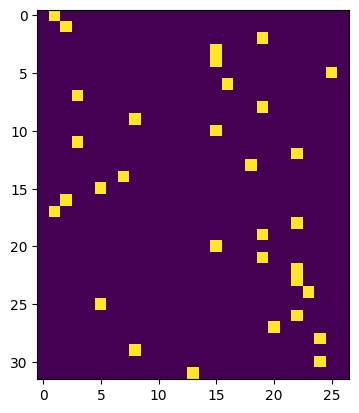

In [12]:
plt.imshow(F.one_hot(logits.max(1).indices,num_classes=logits.shape[1])) # showing from where the maxes came from

In [13]:
loss

tensor(3.3482, grad_fn=<NegBackward0>)

In [14]:
loss_fast = F.cross_entropy(logits,Yb)
print(loss_fast.item(),'diff',(loss_fast - loss).item())

3.348198175430298 diff 0.0


In [15]:
dlogits = F.softmax(logits,1)
dlogits[range(n),Yb] -= 1
dlogits /= n
cmp("logits",dlogits,logits)

logits          | exact: False | approximate: True  | maxdiff: 1.0477378964424133e-08


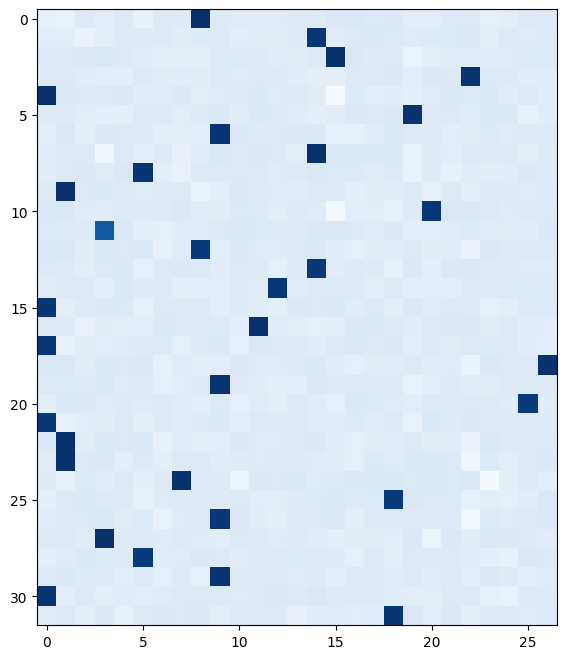

In [16]:
plt.figure(figsize=(8,8))
plt.imshow(dlogits.detach(),cmap='Blues_r');